# Bootstrap results analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from glob import glob

In [2]:
# Re order 
all_results = [
    '../data/bootstrap_results/bootstrap_results_Ab17978_lgbm.npz',
    '../data/bootstrap_results/bootstrap_results_Kp43816_lgbm.npz',
    '../data/bootstrap_results/bootstrap_results_PAO1_lgbm.npz',
    '../data/bootstrap_results/bootstrap_results_AbLac4_lgbm.npz',
    '../data/bootstrap_results/bootstrap_results_Kp0087_lgbm.npz',
    '../data/bootstrap_results/bootstrap_results_Pa0095_lgbm.npz',
]

PLOTS_PATH = "../data/bootstrap_results/plots"

if not os.path.exists(PLOTS_PATH):
    os.makedirs(PLOTS_PATH)

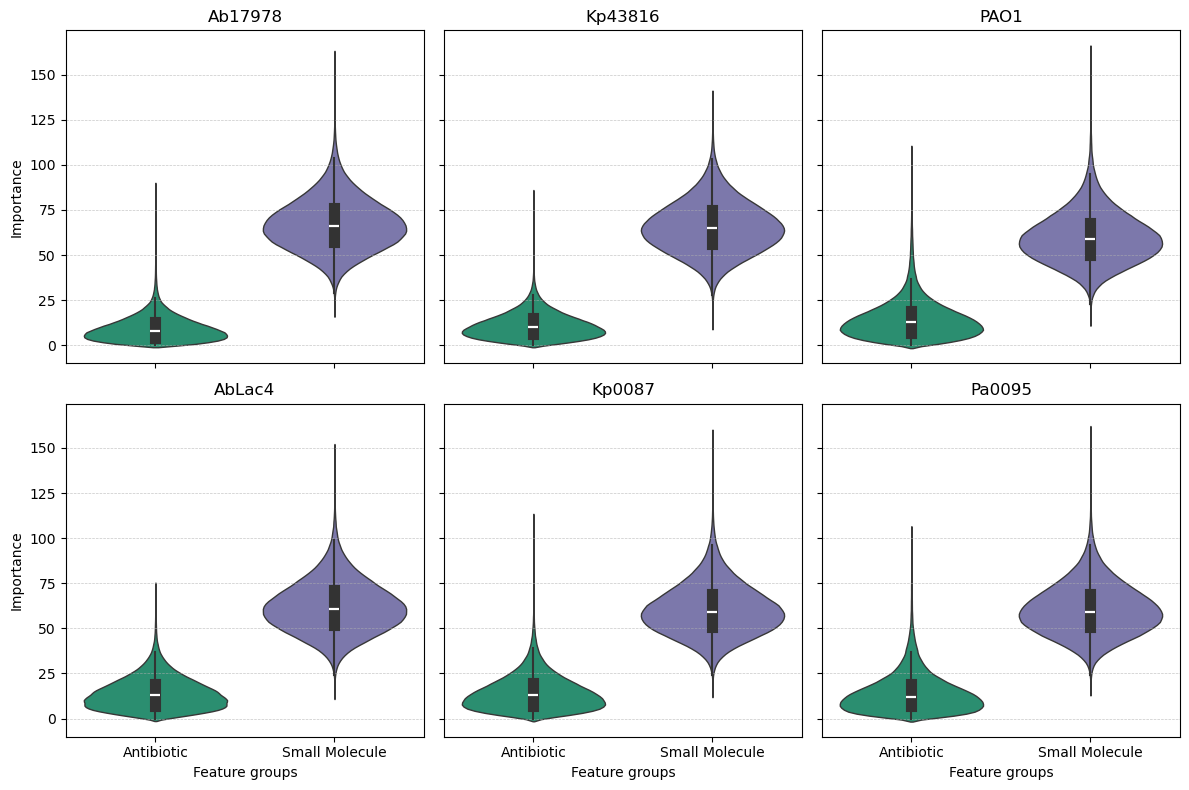

In [ ]:
fig, axes = plt.subplots(2,3, sharex=True, sharey=True, figsize=(12, 8))
# Flatter axes
axes = axes.flatten()

x_values = np.arange(1,768+1, 1)
for i, result_file in enumerate(all_results):
    basename = os.path.basename(result_file)
    # bootstrap_results_AbLac4_lgbm
    strain_name = basename.split('_')[2]
    feature_importance = np.load(result_file, allow_pickle=True)['feature_importances']

    abx_feature_importance = feature_importance[:, :384]
    sm_feature_importance = feature_importance[:, 384:]

    flat_abx_feature_importance = abx_feature_importance.flatten()
    flat_sm_feature_importance = sm_feature_importance.flatten()

    df_abx = pd.DataFrame({'Importance': flat_abx_feature_importance, 'Type': 'Antibiotic'})
    df_sm = pd.DataFrame({'Importance': flat_sm_feature_importance, 'Type': 'Small Molecule'})
    df = pd.concat([df_abx, df_sm])

    # Violin plot
    sns.violinplot(x='Type', y='Importance',
                      data=df,
                      split=False, ax=axes[i],
                      palette=['#1b9e77', '#7570b3'],
                      legend=False, hue = 'Type',
                      inner = "box",
                      inner_kws=dict(box_width=8, whis_width=1.5, color=".2"),
                      linewidth=1) # Red line for the median)
    axes[i].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    axes[i].set_title(f'{strain_name}')
    axes[i].set_xlabel('Feature groups')
    axes[i].set_ylabel('Importance')

plt.tight_layout()

# save in svg format

plt.savefig(os.path.join(PLOTS_PATH, 'feature_importance_violin_plots.svg'), format='svg', dpi=600)


In [25]:
metrics_summary = []
for i, result_file in enumerate(all_results):
    basename = os.path.basename(result_file)
    # bootstrap_results_AbLac4_lgbm
    strain_name = basename.split('_')[2]
    metrics = np.load(result_file, allow_pickle=True)['metrics'].item()
    
    metrics_df = pd.DataFrame(metrics)

    metrics_df['accuracy'] *= 100
    metrics_df['roc_auc'] *= 100
    metrics_df['imcp'] *= 100
    mean = metrics_df.mean()
    std = metrics_df.std()

    metrics_summary.append({
        'strain': strain_name,
        'mean_accuracy': mean['accuracy'],
        'std_accuracy': std['accuracy'],
        'mean_roc_auc': mean['roc_auc'],
        'std_roc_auc': std['roc_auc'],
                'mean_imcp': mean['imcp'],
        'std_imcp': std['imcp'],
                'mean_mcc': mean['mcc'],
        'std_mcc': std['mcc'],
        'mean_log_loss': mean['log_loss'],
        'std_log_loss': std['log_loss']


    })

    

In [26]:
# Print in next format 
# Strain, Accuracy, AU_ROC, Log Loss, IMCP
# {strain}, {mean_accuracy} ± {std_accuracy}, {mean_roc_auc} ± {std_roc_auc},  {mean_log_loss} ± {std_log_loss}, {mean_imcp} ± {std_imcp}
print("Strain, Accuracy, AU_ROC, Log Loss, IMCP, MCC")
for summary in metrics_summary:
    print(f"{summary['strain']}, {summary['mean_accuracy']:.2f} ± {summary['std_accuracy']:.2f}, "
          f"{summary['mean_roc_auc']:.2f} ± {summary['std_roc_auc']:.2f}, "
          f"{summary['mean_log_loss']:.3f} ± {summary['std_log_loss']:.3f}, "
          f"{summary['mean_imcp']:.2f} ± {summary['std_imcp']:.2f} , {summary['mean_mcc']:.3f} ± {summary['std_mcc']:.3f}")
    

Strain, Accuracy, AU_ROC, Log Loss, IMCP, MCC
Ab17978, 82.05 ± 0.27, 81.72 ± 0.30, 0.399 ± 0.005, 63.59 ± 0.24 , 0.276 ± 0.006
Kp43816, 86.71 ± 0.25, 76.41 ± 0.41, 0.313 ± 0.004, 59.19 ± 0.25 , 0.192 ± 0.006
PAO1, 94.49 ± 0.17, 80.13 ± 0.67, 0.191 ± 0.006, 63.66 ± 0.49 , 0.217 ± 0.010
AbLac4, 89.10 ± 0.21, 83.28 ± 0.39, 0.303 ± 0.006, 66.93 ± 0.34 , 0.301 ± 0.007
Kp0087, 92.47 ± 0.19, 86.37 ± 0.43, 0.227 ± 0.005, 70.49 ± 0.41 , 0.345 ± 0.008
Pa0095, 93.47 ± 0.16, 86.24 ± 0.47, 0.208 ± 0.006, 70.94 ± 0.51 , 0.337 ± 0.009
